# Customer Segmentation via RFM Analysis
---

### 1. Overview

Customer segmentation seeks to group customers into groups i.e create market personas so the sales team can better reach them through advertisement. It is different from market segmentation which looks at the whole market (i.e car market), whereat customer segmentation looks at the part of the market the company doing the data analysis caters to.

Customer segmentation may look at Age, Geography, Urbanization, Income, Relationship status, Family or Job type. Furthere, characteristics such ask basket size, share of wallet (how much of a persons income goes to a specific type of spending), tenure (how long they stay with you) or a combination of both.

This heavily depends on the industry, while supermarkets might focus on what products customers buy as 100% share of wallet is unrealistic, an insurance company may go for 100% share of wallet (a customer gets all of his insurances through one company).

### RFM Analysis

Is a method to quantify customer behaviour. It evaluates customers based on three key dimensions:

- Recency (R): How recently did a particular customer make a purchase?
- Frequency (F): How often do they make purchases?
- Monetary Value (M): How much money do they spend?

These values will be mapped to a RFM score on a scale from 1 to 5.

### KMeans Clustering

K-means clustering is an unsupervised learning algorithm used for data clustering, which groups unlabeled data points into groups or clusters.

### 1.1. Content of this Study

We will create clusters using the three key dimensions above to identify customer personas and what their market share of our total customers is. This will also be set into a revenue context. We will additionally compare this data across different market geographies



### 2.1 Reading and Cleaning the Data

This dataset contains online retail sales data, mimicking transactions from an online store platform. It includes information about customer, product details, purchase history, and geography.

| Column Name       | Data Type | Description |
|-------------------|----------|-------------|
| InvoiceNo      | Integer  | Unique identifier for the order |
| StockCode      | String     | Unique identifyer for the product |
| Description      | String  | Information about the product i.e name |
| Quantity     | Integer  | Number of units of the product ordered |
| InvoiceDate   | DateTime   | Date and Time the order was received |
| UnitPrice    | Float   | Price of one unit of the item |
| CustomerID        | Integer  | Unique identifier for the customer |
| Country          | String    | Country of the customer |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel("Online Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

### Proportion of Orders where a given column entry is missing:

In [5]:
prop_nan = pd.Series({column: df.loc[df[column].isna()].shape[0] / df.shape[0] for column in df.columns})
prop_nan

InvoiceNo      0.000000
StockCode      0.000000
Description    0.002683
Quantity       0.000000
InvoiceDate    0.000000
UnitPrice      0.000000
CustomerID     0.249267
Country        0.000000
dtype: float64

In [6]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df_with_id = df.loc[~df["CustomerID"].isna()]
df_without_id = df.loc[df["CustomerID"].isna()]
total_customers = df.groupby("CustomerID").agg({"Country": "first"}).shape[0]
total_id_customers = df_with_id.shape[0]
total_non_id_customers = df_without_id.shape[0]

In [7]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

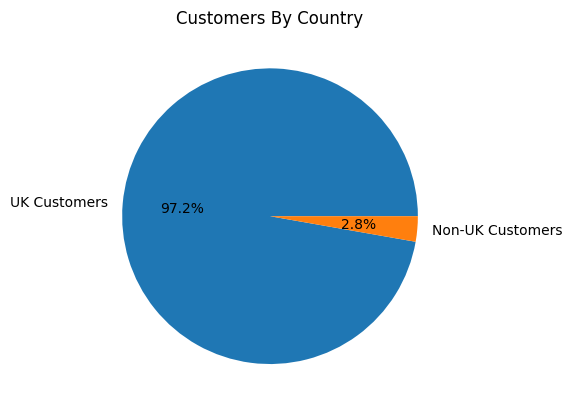

In [8]:
perc_uk_customers = df.groupby("CustomerID").agg({"Country": "first"}).loc[df["Country"] == "United Kingdom"].shape[0] / total_customers

customers_by_country = df.groupby("Country")["Country"].count()
plt.title("Customers By Country")
plt.pie([perc_uk_customers, 1-perc_uk_customers], labels=["UK Customers", "Non-UK Customers"], autopct='%1.1f%%')
plt.show()

### RFM Analysis

In [9]:
reference_date = df_with_id["InvoiceDate"].max()

rfm = df_with_id.groupby("CustomerID").agg({'InvoiceDate': lambda x: (reference_date - x).max().days, "CustomerID": "count", "TotalPrice": "sum"})

rfm = rfm.rename({"InvoiceDate": "Recency", "CustomerID": "Frequency", "TotalPrice": "Monetary Value"}, axis=1)

rfm.head()

,Recency,Frequency,Monetary Value
CustomerID,,,
12346.0,325,2,0.00
12347.0,366,182,4310.00
12348.0,357,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [10]:
# Calculate custom bin edges for Recency, Frequency, and Monetary scores
recency_bins = [rfm['Recency'].min()-1, 20, 50, 150, 250, rfm['Recency'].max()]
frequency_bins = [rfm['Frequency'].min() - 1, 2, 3, 10, 100, rfm['Frequency'].max()]
monetary_bins = [rfm['Monetary Value'].min() - 3, 300, 600, 2000, 5000, rfm['Monetary Value'].max()]

In [11]:

rfm["RScore"] = pd.cut(rfm["Recency"], recency_bins, labels=range(1,6)).astype(int)
rfm["FScore"] = pd.cut(rfm["Frequency"], frequency_bins, labels=range(1,6)).astype(int)
rfm["MScore"] = pd.cut(rfm["Monetary Value"], monetary_bins, labels=range(1,6)).astype(int)

rfm.head()

,Recency,Frequency,Monetary Value,RScore,FScore,MScore
CustomerID,,,,,,
12346.0,325,2,0.00,5,1,1
12347.0,366,182,4310.00,5,5,4
12348.0,357,31,1797.24,5,4,3
12349.0,18,73,1757.55,1,4,3
12350.0,309,17,334.40,5,4,2


In [12]:
X = rfm[["RScore", "FScore", "MScore"]]

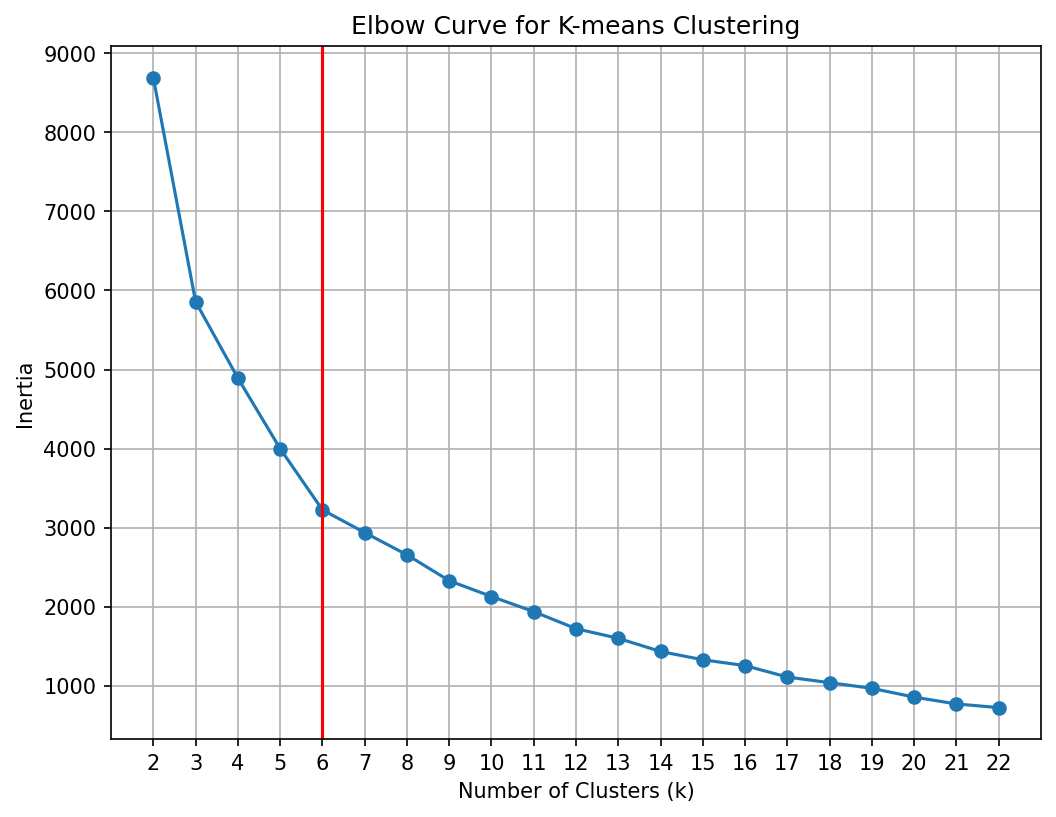

In [13]:
cost_func = []

import numpy as np

for k in range(2, 23):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    cost_func.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 23), cost_func, marker='o')
plt.axvline(6, color="red")
plt.xlabel('Number of Clusters (k)')
plt.xticks(list(range(2,23)))
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

In [14]:
n_opt_clusters = 6
kmeans = KMeans(n_clusters=n_opt_clusters, n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X, )

rfm.head()

,Recency,Frequency,Monetary Value,RScore,FScore,MScore,Cluster
CustomerID,,,,,,,
12346.0,325,2,0.00,5,1,1,4
12347.0,366,182,4310.00,5,5,4,3
12348.0,357,31,1797.24,5,4,3,0
12349.0,18,73,1757.55,1,4,3,5
12350.0,309,17,334.40,5,4,2,1


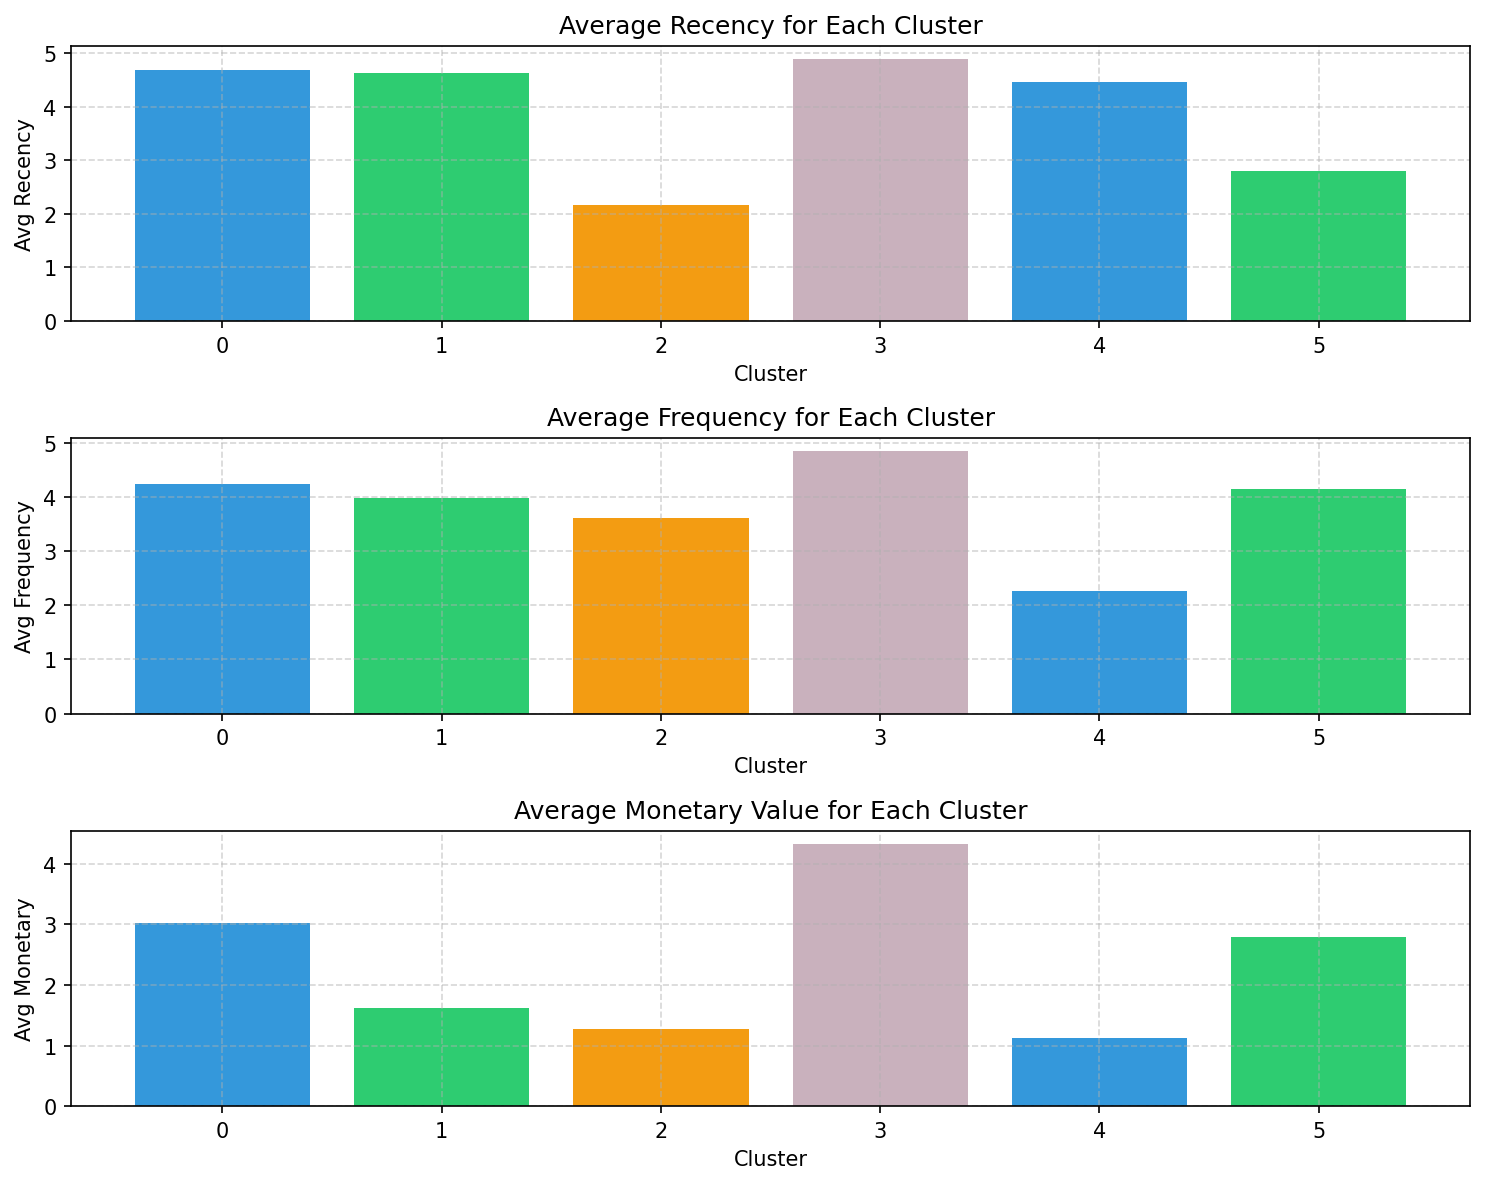

In [15]:
cluster_summary = rfm.groupby('Cluster').agg({
    'RScore': 'mean',
    'FScore': 'mean',
    'MScore': 'mean'
}).reset_index()

colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 8),dpi=150)

# Plot Avg Recency
plt.subplot(3, 1, 1)
bars = plt.bar(cluster_summary.index, cluster_summary['RScore'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)

# Plot Avg Frequency
plt.subplot(3, 1, 2)
bars = plt.bar(cluster_summary.index, cluster_summary['FScore'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)

# Plot Avg Monetary
plt.subplot(3, 1, 3)
bars = plt.bar(cluster_summary.index, cluster_summary['MScore'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Clusters:

- Cluster 0: Medium Budget Loyal Customers
- Cluster 1: Low Budget Loyal Customers
- Cluster 2: Low Budget Risk Customers
- Cluster 3: Champion Customers
- Cluster 4: Recent Customers
- Cluster 5: Medium to High Budget Customers at Risk

In [16]:
cluster_counts = rfm['Cluster'].value_counts()

colors = ["#D32F2F", "#B71C1C","#66BB6A", "#4CAF50", "#1976D2", "#FFC107", "#FF5252"]
# Calculate the total number of customers
total_customers = cluster_counts.sum()

# Calculate the percentage of customers in each cluster
percentage_customers = (cluster_counts / total_customers) * 100

labels = ["Medium Budget Loyal Customers", "Low Budget Loyal Customers", "Low Budget Risk Customers", "Chamption Customers", "Recent Customers", "Medium to High Budget Customers at Risk"]
# Create a pie chart

# plt.figure(figsize=(8, 8),dpi=200)
# plt.pie(percentage_customers[[2, 5, 1, 0, 3, 4]], labels=pd.Series(labels)[[2, 5, 1, 0, 3, 4]], autopct='%1.1f%%', startangle=90, colors=colors)
# plt.title('Percentage of Customers in Each Cluster (Global)')

# plt.show()

import plotly.graph_objects as go

fig = go.Figure(data=[go.Pie(labels=pd.Series(labels)[[2, 5, 1, 0, 3, 4]], values=percentage_customers[[2, 5, 1, 0, 3, 4]],
                             hole=0.55, marker=dict(colors=colors),
                             textinfo='percent')])  # hole > 0 for donut chart
fig.update_layout(title='Percentage of Customers in Each Cluster (Global)')
fig.show()

In [17]:
non_uk_customers = df_with_id.loc[df_with_id["Country"] != "United Kingdom"]
rfm_non_uk = rfm.join(non_uk_customers, how="inner", on="CustomerID")

cluster_counts_non_uk = rfm_non_uk['Cluster'].value_counts()

colors = ["#D32F2F", "#B71C1C","#66BB6A", "#4CAF50", "#1976D2", "#FFC107", "#FF5252"]
# Calculate the total number of customers
total_customers = cluster_counts_non_uk.sum()

# Calculate the percentage of customers in each cluster
percentage_customers_non_uk = (cluster_counts_non_uk / non_uk_customers.shape[0]) * 100

labels = ["Medium Budget Loyal Customers", "Low Budget Loyal Customers", "Low Budget Risk Customers", "Chamption Customers", "Recent Customers", "Medium to High Budget Customers at Risk"]
# Create a pie chart
# plt.figure(figsize=(8, 8),dpi=200)
# plt.pie(percentage_customers_non_uk[[2, 5, 1, 0, 3, 4]], labels=pd.Series(labels)[[2, 5, 1, 0, 3, 4]], autopct='%1.1f%%', startangle=90, colors=colors)
# plt.title('Percentage of Customers in Each Cluster (Non UK / International)')

# plt.show()

fig = go.Figure(data=[go.Pie(labels=pd.Series(labels)[[2, 5, 1, 0, 3, 4]], values=percentage_customers_non_uk[[2, 5, 1, 0, 3, 4]],
                             hole=0.55, marker=dict(colors=colors),
                             textinfo='percent')])  # hole > 0 for donut chart
fig.update_layout(title='Percentage of Customers in Each Cluster (Non UK / International)')
fig.show()

### Results:

- The platform is losing customers long term as there are more customers at risk compared to the inflow of new recent customers
- The platform losing disproportionally many high budget customers, as their number should be far lower compared to the low budget customers. This is especially a problem for UK customers.
- The platform still gains more UK customers than international customers (proportionally and in absolute terms)
- Loyal Customer share similar between UK and non-UK

### Suggestions

- Increase customer binding starting with high budget UK customers i.e via starting a loyalty program or strengthening an existing one.
- Invest heavily in gaining more new non-UK customers as there lies the biggest potential.
